In [ ]:

import pandas as pd
import numpy as np
from sklearn.metrics import mutual_info_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import KBinsDiscretizer
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt



In [ ]:
# ---------------------------
# 1. Load preprocessed data and labels
# ---------------------------
import os

os.chdir('C:/Users/p528552/OneDrive - South African Reserve Bank/Documents/1. MEng - Data Science/1. Project_2025/Data/factor_timing/data_input')

# Data import:
df_factor = pd.read_csv("labeled_relative_factor_returns.csv", parse_dates=['Date'])
df_factor = df_factor[['Date','Momentum_vs_Value_trend']]    # trend_bin = trend label
df_factor = df_factor.set_index('Date')

df_features = pd.read_csv("featureset.csv", parse_dates=['Date'])
#df_features = df_features.drop(['Momentum_vs_Quality_trend'],axis=1)
df_features = df_features.set_index('Date')


data = pd.concat([df_features,df_factor], axis=1, join='inner')
data = data.dropna()
feature_names = data.columns[:-1].tolist()


X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values
feature_names = data.columns[:-1].tolist()


X = pd.DataFrame(X, columns=feature_names)


In [ ]:

# ---------------------------
# 2. Compute Mutual Information between features and target
# ---------------------------
def compute_mi_scores(X, y, discrete_features='auto'):
    mi_scores = mutual_info_classif(X, y, discrete_features=discrete_features, random_state=42)
    mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
    return mi_series

mi_scores = compute_mi_scores(X, y)
print(mi_scores.head())



LEI.TOTL.Index    0.329484
OEZAKLAF_YoY      0.314391
MichgnConcIndx    0.305436
SAPMI_YoY         0.301556
EPUCCUSM.Index    0.298696
dtype: float64


In [ ]:
# ---------------------------
# 3. Compute pairwise normalized Mutual Information between features
# ---------------------------
def normalized_mi(x, y, n_bins=20):
    """Compute normalized MI between two continuous features."""
    kb = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='uniform')
    x_binned = kb.fit_transform(x.reshape(-1, 1))
    y_binned = kb.fit_transform(y.reshape(-1, 1))
    mi = mutual_info_score(x_binned[:, 0], y_binned[:, 0])
    h_x = mutual_info_score(x_binned[:, 0], x_binned[:, 0])
    h_y = mutual_info_score(y_binned[:, 0], y_binned[:, 0])
    return mi / max(h_x, h_y)

def mi_distance_matrix(X):
    """Return MI-based distance matrix (1 - normalized_MI)."""
    n = X.shape[1]
    dist_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            nmi = normalized_mi(X.iloc[:, i].values, X.iloc[:, j].values)
            dist = 1 - nmi
            dist_matrix[i, j] = dist_matrix[j, i] = dist
    return pd.DataFrame(dist_matrix, index=X.columns, columns=X.columns)

# Example:
D = mi_distance_matrix(X)
# D.to_csv("MI_distance_matrix.csv")


c:\Users\p528552\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:262: UserWarning: Feature 0 is constant and will be replaced with 0.
  warnings.warn(
c:\Users\p528552\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:262: UserWarning: Feature 0 is constant and will be replaced with 0.
  warnings.warn(
c:\Users\p528552\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:262: UserWarning: Feature 0 is constant and will be replaced with 0.
  warnings.warn(
c:\Users\p528552\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:262: UserWarning: Feature 0 is constant and will be replaced with 0.
  warnings.warn(
c:\Users\p528552\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:262: UserWarning: Feature 0 is constant and will be replaced with 0.
  warnings.warn(
c:\Users\p528552\AppData\Local\anaconda3\Lib\site-packages\sklearn\pre

ZeroDivisionError: float division by zero

In [ ]:

# ---------------------------
# 4. Hierarchical clustering using MI-based distances
# ---------------------------
def mi_hierarchical_clustering(D, mi_scores, n_clusters=None, threshold=None):
    """Perform hierarchical clustering using MI distances and select cluster representatives."""
    # Convert to condensed distance format
    condensed_D = squareform(D.values, checks=False)
    Z = linkage(condensed_D, method='average')

    # Plot dendrogram
    plt.figure(figsize=(12, 6))
    dendrogram(Z, labels=D.columns, leaf_rotation=90)
    plt.title("MI-Based Feature Clustering Dendrogram")
    plt.tight_layout()
    plt.show()

    # Cluster cutoff (either number of clusters or distance threshold)
    if threshold:
        clusters = fcluster(Z, t=threshold, criterion='distance')
    elif n_clusters:
        clusters = fcluster(Z, t=n_clusters, criterion='maxclust')
    else:
        raise ValueError("Specify either n_clusters or threshold.")

    cluster_df = pd.DataFrame({'feature': D.columns, 'cluster': clusters})
    cluster_representatives = []
    for c in cluster_df['cluster'].unique():
        members = cluster_df.loc[cluster_df['cluster'] == c, 'feature']
        # pick feature with highest MI-to-y within cluster
        rep = mi_scores[members].idxmax()
        cluster_representatives.append(rep)

    return cluster_representatives, cluster_df



In [ ]:
# Example usage:


#selected_features, threshold = csfs_mi_pipeline(X, y)

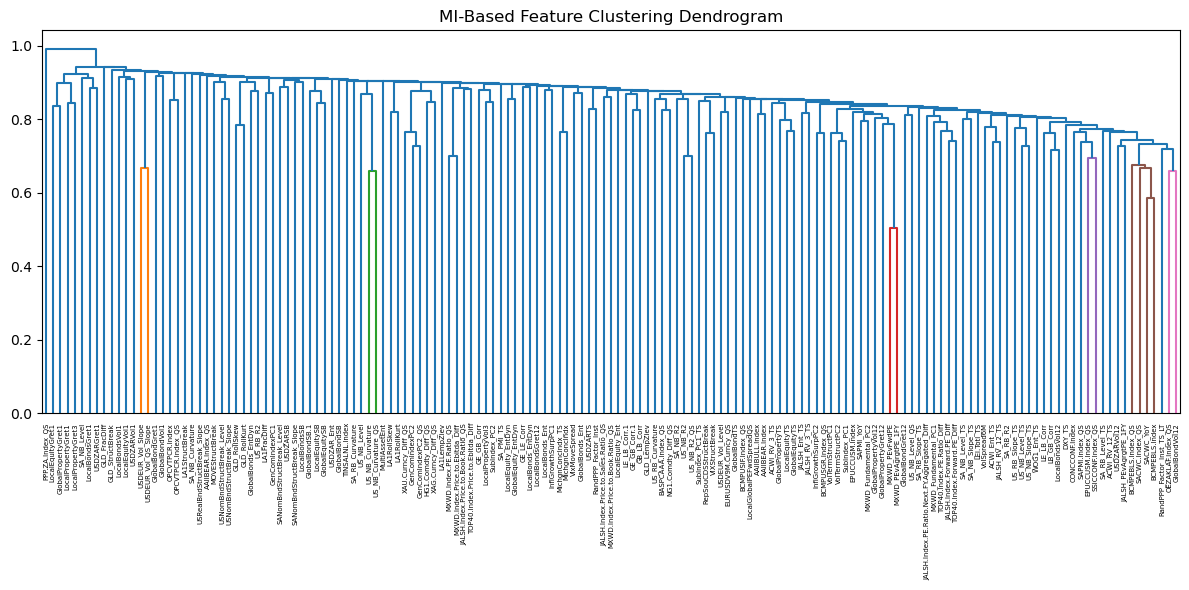

Selected Features: ['EPUCCUSM.Index', 'OPCVTPCR.Index', 'AAIIBEAR.Index_QS', 'GLD_StructBreak', 'GLD_RollSkew', 'GenComIndexPC1', 'LA1StructBreak', 'USNomBndStructBreak_Slope', 'USRealBndStructBreak_Slope', 'LocalPropertyGret3', 'LocalEquityVol1', 'USDZARGret1', 'LocalBondsVol1', 'GlobalBondGret1', 'GlobalBondVol1', 'PPP.ZA.Index_QS', 'GLD_FracDiff', 'SA_NB_Level', 'SA_NB_Curvature', 'USDEUR_Vol_QS_Slope']


In [ ]:
# Example workflow:
mi_scores = compute_mi_scores(X, y)
D = mi_distance_matrix(X)
selected_features, clusters = mi_hierarchical_clustering(D, mi_scores, n_clusters=20)
print("Selected Features:", selected_features)

# ---------------------------
# 5. Save outputs
# ---------------------------
pd.Series(selected_features).to_csv("selected_features_MI_clustered.csv", index=False)
clusters.to_csv("MI_feature_clusters.csv", index=False)
